# L3.1 — The Artificial Neuron

Hands-on notebook for the lesson [`3-1-neuron.mdx`](../../llm-quest-theory/level-3/3-1-neuron.mdx).

> **Learning objectives**
> - Implement a single neuron `y = sigma(w^T x + b)` in NumPy and watch what `w`, `b` do geometrically.
> - Compare 5 common activation functions — sigmoid, tanh, ReLU, LeakyReLU, GELU — and their derivatives.
> - Train a single neuron on a linearly separable 2-D dataset and see the decision boundary.
> - Prove to yourself that without a non-linearity, stacking N linear layers collapses to 1 linear layer.

## Connection to the theory
Covers **§1–§4** of the source `.mdx`. This is the first half of "deep learning from scratch" — lesson 3-2 stacks these neurons into an MLP.

In [1]:
# ---- Setup ----
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. The neuron equation

$$y = \sigma(w_1 x_1 + w_2 x_2 + \ldots + w_n x_n + b) = \sigma(\mathbf{w}^\top \mathbf{x} + b)$$

Two parts: a linear pre-activation `z` and a non-linear activation `sigma(z)`.

In [2]:
def neuron(x, w, b, activation=None):
    z = np.dot(w, x) + b
    if activation is None:
        return z
    return activation(z)

# One neuron that asks "is 2 x1 + x2 + bias positive?"
w = np.array([2.0, 1.0])
b = -0.5
for x in [np.array([0.0, 0.0]), np.array([1.0, 1.0]), np.array([-1.0, -1.0])]:
    print(f"x = {x}  z = {neuron(x, w, b):+.2f}")

x = [0. 0.]  z = -0.50
x = [1. 1.]  z = +2.50
x = [-1. -1.]  z = -3.50


## 2. Activation zoo
Plot sigmoid, tanh, ReLU, LeakyReLU, GELU side by side.

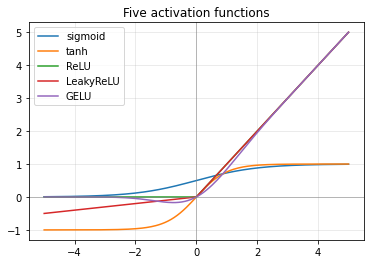

In [3]:
def sigmoid(z): return 1.0 / (1.0 + np.exp(-z))
def tanh(z):    return np.tanh(z)
def relu(z):    return np.maximum(0.0, z)
def leaky_relu(z, slope=0.1): return np.where(z > 0, z, slope * z)
def gelu(z):
    return 0.5 * z * (1.0 + np.tanh(np.sqrt(2 / np.pi) * (z + 0.044715 * z ** 3)))

activations = {
    "sigmoid":     sigmoid,
    "tanh":        tanh,
    "ReLU":        relu,
    "LeakyReLU":   leaky_relu,
    "GELU":        gelu,
}

z = np.linspace(-5, 5, 200)
fig, ax = plt.subplots()
for name, fn in activations.items():
    ax.plot(z, fn(z), label=name)
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.grid(alpha=0.3); ax.legend()
ax.set_title("Five activation functions")
plt.show()

## 3. The derivative tells the training story
The size of each activation's derivative controls how much gradient flows backward — we compute numerical derivatives and compare.

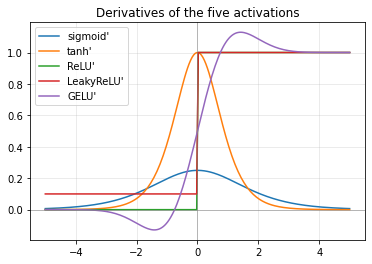

In [4]:
def num_deriv(f, z, h=1e-4):
    return (f(z + h) - f(z - h)) / (2 * h)

fig, ax = plt.subplots()
for name, fn in activations.items():
    ax.plot(z, num_deriv(fn, z), label=f"{name}'")
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.grid(alpha=0.3); ax.legend()
ax.set_title("Derivatives of the five activations")
plt.show()

Read the plot:
- Sigmoid / tanh: derivatives peak at 0 (0.25 and 1.0), and vanish for `|z| > 3`. Stacking many such layers shrinks the gradient — the classic vanishing-gradient problem.
- ReLU: derivative is either 0 or 1. No vanishing for `z > 0`, but neurons that see only `z < 0` die permanently.
- LeakyReLU: keeps a small slope for `z < 0` — no dead neurons.
- GELU: a smooth cousin of ReLU, derivative is continuous everywhere.

## 4. Training a single neuron (logistic regression, again)
We use a 2-D dataset where class 1 is `2 x1 + x2 > 0`. Gradient descent on BCE should recover `w ~ (2, 1)`, `b ~ 0`.

In [5]:
N = 300
X = np.random.uniform(-3, 3, size=(N, 2))
y = (2 * X[:, 0] + X[:, 1] + np.random.normal(0, 0.3, size=N) > 0).astype(float)

def bce(y, y_hat, eps=1e-12):
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return float(-np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat)))

def train_neuron(X, y, lr=0.3, n_steps=1000):
    w = np.zeros(2)
    b = 0.0
    losses = []
    for _ in range(n_steps):
        z = X @ w + b
        y_hat = sigmoid(z)
        grad_w = X.T @ (y_hat - y) / len(y)
        grad_b = float(np.mean(y_hat - y))
        w -= lr * grad_w
        b -= lr * grad_b
        losses.append(bce(y, y_hat))
    return w, b, losses

w_star, b_star, losses = train_neuron(X, y)
print(f"learned  w = {np.round(w_star, 3)},  b = {round(b_star, 3)}")
print(f"expected w ~ [2, 1],           b ~ 0")

learned  w = [5.374 2.895],  b = -0.121
expected w ~ [2, 1],           b ~ 0


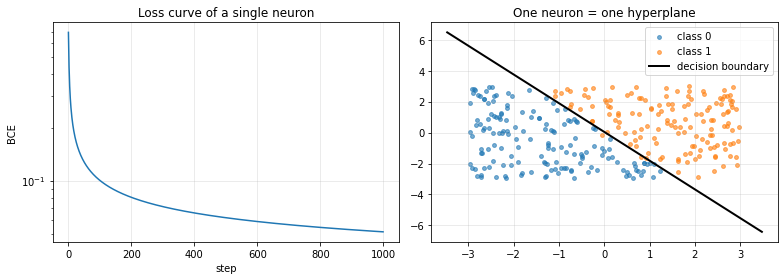

In [6]:
# Decision boundary: w1 x1 + w2 x2 + b = 0  -->  x2 = -(w1 x1 + b)/w2
xs = np.array([X[:, 0].min() - 0.5, X[:, 0].max() + 0.5])
boundary = -(w_star[0] * xs + b_star) / w_star[1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(losses); axes[0].set_yscale("log")
axes[0].set_xlabel("step"); axes[0].set_ylabel("BCE"); axes[0].grid(alpha=0.3)
axes[0].set_title("Loss curve of a single neuron")

axes[1].scatter(X[y == 0, 0], X[y == 0, 1], s=15, label="class 0", alpha=0.6)
axes[1].scatter(X[y == 1, 0], X[y == 1, 1], s=15, label="class 1", alpha=0.6)
axes[1].plot(xs, boundary, "k-", lw=2, label="decision boundary")
axes[1].grid(alpha=0.3); axes[1].legend(); axes[1].set_title("One neuron = one hyperplane")
plt.tight_layout(); plt.show()

## 5. Why non-linearity is mandatory
Stack three linear layers without activation. Show that the whole stack is equivalent to a single linear map `(W3 W2 W1)`.

In [7]:
rng = np.random.default_rng(SEED)
W1 = rng.normal(size=(4, 2))
W2 = rng.normal(size=(3, 4))
W3 = rng.normal(size=(2, 3))

x = rng.normal(size=2)

# Three linear layers with NO activation
h1 = W1 @ x
h2 = W2 @ h1
out_deep = W3 @ h2

# Equivalent single linear map
W_combined = W3 @ W2 @ W1
out_single = W_combined @ x

print("deep (no activation) output:", np.round(out_deep,   4))
print("single-layer equivalent    :", np.round(out_single, 4))
print("match?                     :", np.allclose(out_deep, out_single))

deep (no activation) output: [-2.3298  0.9889]
single-layer equivalent    : [-2.3298  0.9889]
match?                     : True


Now add a ReLU between every linear layer and the equivalence disappears — the non-linearity is what gives depth its power.

In [8]:
h1_nl  = relu(W1 @ x)
h2_nl  = relu(W2 @ h1_nl)
out_nl = W3 @ h2_nl

print("deep (with ReLU) output    :", np.round(out_nl,     4))
print("single-layer equivalent    :", np.round(out_single, 4))
print("match?                     :", np.allclose(out_nl, out_single))

deep (with ReLU) output    : [-0.5705 -0.3588]
single-layer equivalent    : [-2.3298  0.9889]
match?                     : False


## 6. Quick checks

In [9]:
# Sigmoid derivative at 0 is 0.25
assert abs(num_deriv(sigmoid, 0.0) - 0.25) < 1e-3
# Tanh derivative at 0 is 1
assert abs(num_deriv(tanh, 0.0) - 1.0) < 1e-3
# ReLU derivative is 1 for positive z
assert abs(num_deriv(relu, 1.5) - 1.0) < 1e-3
# Trained neuron recovers the ratio w1/w2 ≈ 2
assert abs(w_star[0] / w_star[1] - 2.0) < 0.3
# Linear-only stack collapses, ReLU stack does not
assert np.allclose(out_deep, out_single)
assert not np.allclose(out_nl, out_single)
print("OK — activations behave, neuron trains, non-linearity matters.")

OK — activations behave, neuron trains, non-linearity matters.


## Reflection questions

1. A sigmoid-only deep MLP struggles to train past ~10 layers. Which part of the derivative curve in section 3 makes this visible?
2. ReLU has a "dead neuron" failure mode. Can you construct an input distribution and initialisation where *most* ReLU neurons die? What does LeakyReLU change?
3. GELU is the default in modern Transformers. Looking at its derivative, why is it preferable to ReLU for sub-word language models?
4. A single neuron can only draw one hyperplane. Design a 2-D dataset that no single neuron can classify with more than 60% accuracy — and plot it.

## References
- Source theory: [`3-1-neuron.mdx`](../../llm-quest-theory/level-3/3-1-neuron.mdx)
- Next: [`3-2-mlp`](3-2-mlp.ipynb)